<a href="https://colab.research.google.com/github/Tayli05/INTELIGENCIA-ARTIFICIAL-1/blob/main/Lab6-pytorch_labs_1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

# PyTorch - Regresión y Clasificación
### Dataset/DataLoader, Optimizadores, Checkpoints y Métricas

En este cuadernillo reimplementamos los 5 laboratorios utilizando **PyTorch de forma completa**, incorporando los elementos que pidió el docente:

1. **`Dataset` y `DataLoader`**: los datos ya no se pasan al modelo de una sola vez (full-batch); se organizan en una clase `Dataset` y se recorren en mini-lotes con `DataLoader`.
2. **Objetos de Optimización (`torch.optim`)**: reemplazamos la actualización manual de gradientes (`param -= lr * param.grad`) por un objeto `optimizer` (`optim.SGD` / `optim.Adam`) que llama a `optimizer.step()` y `optimizer.zero_grad()`.
3. **Objetos para guardar pesos**: cada modelo entrenado se guarda con `torch.save(model.state_dict(), 'archivo.pth')`, generando un checkpoint reutilizable.
4. **Métricas ampliadas**: además de la pérdida, calculamos MAE/R² (regresión) y precisión, recall, F1 y matriz de confusión (clasificación).
5. **Mismo criterio de división**: 80% Entrenamiento / 20% Prueba, de forma manual con permutaciones, igual que en la versión original.


## 1. Configuración del Entorno, Importaciones y Utilidades Comunes

In [1]:
# Importaciones generales
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, r2_score
)

# Seleccionar dispositivo (GPU si está disponible, de lo contrario CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')
print(f'Versión de PyTorch: {torch.__version__}')

Dispositivo en uso: cuda
Versión de PyTorch: 2.11.0+cu128


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Clase `Dataset` genérica

En vez de definir una clase `Dataset` distinta para cada laboratorio, creamos **una sola clase reutilizable** que envuelve cualquier par de tensores `(X, y)`. Esta misma clase se usará en los 5 laboratorios, solo cambiando los datos que le pasamos.

In [3]:
class TensorDataset(Dataset):
    """Dataset genérico: envuelve tensores X (features) e y (target)
    para poder recorrerlos en mini-lotes con DataLoader."""

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### 1.2 Función de entrenamiento genérica

Todos los laboratorios (excepto la Ecuación de la Normal, que no se entrena por gradiente) siguen el mismo patrón:
recorrer el `DataLoader` por épocas, calcular la pérdida, hacer `backward()` y actualizar con el `optimizer`. Escribimos esa lógica una sola vez para no repetir código.

In [4]:
def entrenar_modelo(model, train_loader, criterion, optimizer, epochs, imprimir_cada=20):
    """Bucle de entrenamiento genérico usando DataLoader + optimizer.
    Devuelve el historial de pérdida promedio por época."""
    loss_history = []

    for epoch in range(epochs):
        model.train()
        loss_acumulada = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()                 # limpiar gradientes del batch anterior
            y_pred = model(X_batch)               # forward pass
            loss = criterion(y_pred, y_batch)     # calcular pérdida
            loss.backward()                       # backward pass (autograd)
            optimizer.step()                      # actualizar pesos

            loss_acumulada += loss.item() * X_batch.size(0)

        loss_epoca = loss_acumulada / len(train_loader.dataset)
        loss_history.append(loss_epoca)

        if (epoch + 1) % imprimir_cada == 0:
            print(f'Época [{epoch+1}/{epochs}], Pérdida Train: {loss_epoca:.4f}')

    return loss_history

## 2. Regresión Lineal Simple (Lab 1)
Predecimos una variable continua $y$ a partir de una única variable explicativa $x$: $y = w \cdot x + b$.

In [28]:
# Cargar el dataset de regresión simple
df_simple = pd.read_csv('/content/drive/MyDrive/InteligenciaArtificial/bdi_and_screen_items.csv')
print(f'Total de muestras en el dataset: {len(df_simple)}')
df_simple.head()

Total de muestras en el dataset: 4810


,subject_id,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6,bdi_item_01,bdi_item_02,...,bdi_item_12,bdi_item_13,bdi_item_14,bdi_item_15,bdi_item_16,bdi_item_17,bdi_item_18,bdi_item_19,bdi_item_20,bdi_item_21
0,1,2,3,5,1,3,2,3,0,1,...,0,1,0,0,0,0,0,1,0,0
1,2,3,3,4,4,2,3,1,1,0,...,1,1,0,1,1,0,0,0,1,0
2,3,3,3,4,3,1,3,1,1,1,...,2,1,1,1,1,1,1,2,2,1
3,4,4,4,5,2,1,2,1,0,1,...,3,0,0,2,2,1,0,0,1,0
4,5,3,1,1,2,2,4,2,0,0,...,0,0,0,0,1,0,1,0,0,0


In [29]:
# División Manual de Datos (80% Train / 20% Test)
bdi_cols = [c for c in df_simple.columns if c.startswith('bdi_item_')]
df_simple['bdi_total'] = df_simple[bdi_cols].sum(axis=1)

X_simple = df_simple[['screen_normal_day_1to6']].values
y_simple = df_simple[['bdi_total']].values

np.random.seed(42)
total_samples = len(X_simple)
train_size = int(total_samples * 0.8)

indices = np.random.permutation(total_samples)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train_s, y_train_s = X_simple[train_idx], y_simple[train_idx]
X_test_s, y_test_s = X_simple[test_idx], y_simple[test_idx]

print(f'Muestras de Entrenamiento (Train 80%): {len(X_train_s)}')
print(f'Muestras de Prueba (Test 20%): {len(X_test_s)}')

Muestras de Entrenamiento (Train 80%): 3848
Muestras de Prueba (Test 20%): 962


In [30]:
# Normalización z-score basada exclusivamente en Train
mu_s, std_s = X_train_s.mean(), X_train_s.std()
X_train_s_norm = (X_train_s - mu_s) / std_s
X_test_s_norm = (X_test_s - mu_s) / std_s

X_train_s_tensor = torch.tensor(X_train_s_norm, dtype=torch.float32).to(device)
y_train_s_tensor = torch.tensor(y_train_s, dtype=torch.float32).to(device)
X_test_s_tensor = torch.tensor(X_test_s_norm, dtype=torch.float32).to(device)
y_test_s_tensor = torch.tensor(y_test_s, dtype=torch.float32).to(device)

In [31]:
# Dataset y DataLoader
train_dataset_s = TensorDataset(X_train_s_tensor, y_train_s_tensor)
train_loader_s = DataLoader(train_dataset_s, batch_size=32, shuffle=True)

In [32]:
# Definición de la arquitectura del modelo
class RegresionLinealSimple(nn.Module):
    def __init__(self):
        super(RegresionLinealSimple, self).__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

In [38]:
# Hiperparámetros
learning_rate_simple = 0.05
epochs_simple = 200

# Modelo, función de costo y OPTIMIZADOR (NUEVO: reemplaza la actualización manual)
model_simple = RegresionLinealSimple().to(device)
criterion_mse = nn.MSELoss()
optimizer_simple = optim.SGD(model_simple.parameters(), lr=learning_rate_simple)

# Entrenamiento usando la función genérica (DataLoader + optimizer)
loss_history = entrenar_modelo(model_simple, train_loader_s, criterion_mse, optimizer_simple, epochs_simple)

Época [20/200], Pérdida Train: 57.0682
Época [40/200], Pérdida Train: 57.1121
Época [60/200], Pérdida Train: 57.0676
Época [80/200], Pérdida Train: 57.0135
Época [100/200], Pérdida Train: 57.0497
Época [120/200], Pérdida Train: 57.0461
Época [140/200], Pérdida Train: 57.0778
Época [160/200], Pérdida Train: 57.0840
Época [180/200], Pérdida Train: 57.0528
Época [200/200], Pérdida Train: 57.0580


In [34]:
# Guardar los pesos del modelo entrenado (NUEVO)
torch.save(model_simple.state_dict(), 'model_simple.pth')
print('Pesos guardados en model_simple.pth')

# Para volver a cargarlos en el futuro:
# model_simple.load_state_dict(torch.load('model_simple.pth'))

Pesos guardados en model_simple.pth


In [35]:
# Evaluación en Test + Métricas ampliadas (NUEVO: MAE y R^2 además de MSE)
model_simple.eval()
with torch.no_grad():
    y_pred_test = model_simple(X_test_s_tensor)
    loss_test_s = criterion_mse(y_pred_test, y_test_s_tensor)

y_pred_test_np = y_pred_test.cpu().numpy()
y_test_s_np = y_test_s_tensor.cpu().numpy()

mae_s = mean_absolute_error(y_test_s_np, y_pred_test_np)
r2_s = r2_score(y_test_s_np, y_pred_test_np)

print(f'Pérdida MSE Final en Entrenamiento (Train 80%): {loss_history[-1]:.4f}')
print(f'Pérdida MSE Final en Prueba (Test 20%): {loss_test_s.item():.4f}')
print(f'MAE en Prueba: {mae_s:.4f}')
print(f'R² en Prueba: {r2_s:.4f}')

Pérdida MSE Final en Entrenamiento (Train 80%): 57.3344
Pérdida MSE Final en Prueba (Test 20%): 63.2053
MAE en Prueba: 5.7838
R² en Prueba: 0.0140


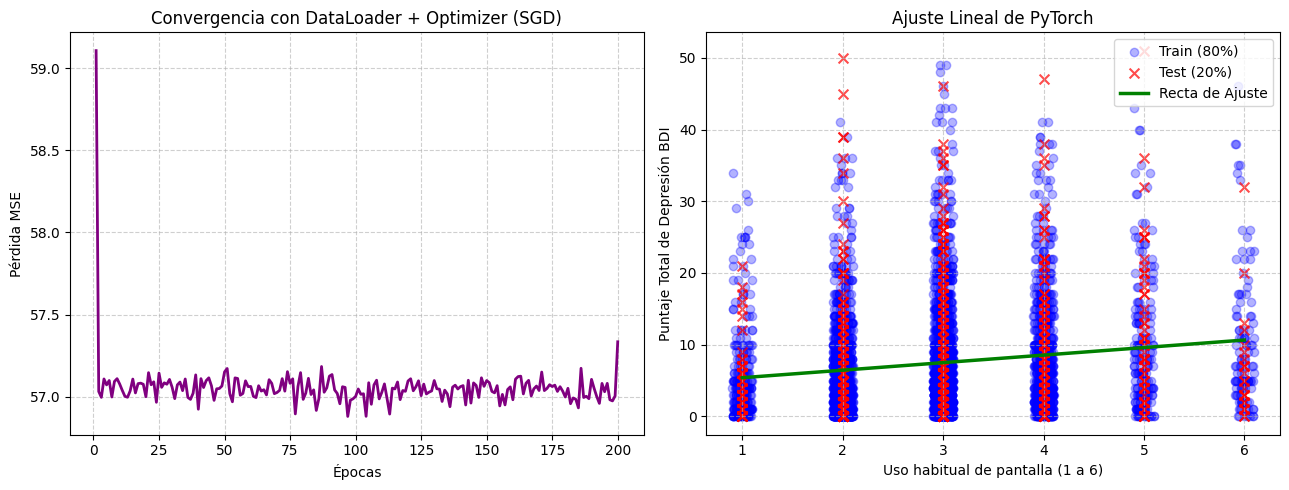

In [36]:
# Gráficas de la curva de costo y la recta de ajuste sobre Train y Test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, epochs_simple + 1), loss_history, color='purple', linewidth=2)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida MSE')
ax1.set_title('Convergencia con DataLoader + Optimizer (SGD)')
ax1.grid(True, linestyle='--', alpha=0.6)

jitter = (np.random.rand(*X_train_s.shape) - 0.5) * 0.2
ax2.scatter(X_train_s + jitter, y_train_s, color='blue', alpha=0.3, label='Train (80%)')
ax2.scatter(X_test_s, y_test_s, color='red', marker='x', s=50, alpha=0.7, label='Test (20%)')

x_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
x_range_norm = (x_range - mu_s) / std_s
x_range_tensor = torch.tensor(x_range_norm, dtype=torch.float32).to(device)

with torch.no_grad():
    y_range_pred = model_simple(x_range_tensor).cpu().numpy()

ax2.plot(x_range, y_range_pred, color='green', linewidth=2.5, label='Recta de Ajuste')
ax2.set_xlabel('Uso habitual de pantalla (1 a 6)')
ax2.set_ylabel('Puntaje Total de Depresión BDI')
ax2.set_title('Ajuste Lineal de PyTorch')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 3. Regresión Lineal Múltiple, Polinómica y Ecuación de la Normal (Lab 2)

In [ ]:
# Cargar dataset multivariable
df_multi = pd.read_csv('/content/drive/MyDrive/InteligenciaArtificial/energydata_complete - copia.csv')
df_multi.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
# División Manual de Datos (80% Train / 20% Test)
X_m = df_multi.drop(columns=['date', 'Appliances']).values
y_m = df_multi[['Appliances']].values

np.random.seed(42)
total_m = len(X_m)
train_size_m = int(total_m * 0.8)

indices_m = np.random.permutation(total_m)
train_idx_m = indices_m[:train_size_m]
test_idx_m = indices_m[train_size_m:]

X_train_m, y_train_m = X_m[train_idx_m], y_m[train_idx_m]
X_test_m, y_test_m = X_m[test_idx_m], y_m[test_idx_m]

mu_m, std_m = X_train_m.mean(axis=0), X_train_m.std(axis=0)
X_train_m_norm = (X_train_m - mu_m) / std_m
X_test_m_norm = (X_test_m - mu_m) / std_m

X_train_m_tensor = torch.tensor(X_train_m_norm, dtype=torch.float32).to(device)
y_train_m_tensor = torch.tensor(y_train_m, dtype=torch.float32).to(device)
X_test_m_tensor = torch.tensor(X_test_m_norm, dtype=torch.float32).to(device)
y_test_m_tensor = torch.tensor(y_test_m, dtype=torch.float32).to(device)

print(f'Train Muestras (80%): {len(X_train_m)}, Test Muestras (20%): {len(X_test_m)}')

Train Muestras (80%): 16028, Test Muestras (20%): 4007


In [ ]:
# Dataset y DataLoader (NUEVO)
train_dataset_m = TensorDataset(X_train_m_tensor, y_train_m_tensor)
train_loader_m = DataLoader(train_dataset_m, batch_size=64, shuffle=True)

In [ ]:
# 1. Regresión Lineal Múltiple
learning_rate_multi = 0.01
epochs_multi = 200

num_features = X_train_m_tensor.shape[1]
model_multi = nn.Linear(in_features=num_features, out_features=1).to(device)
criterion_mse = nn.MSELoss()
optimizer_multi = optim.SGD(model_multi.parameters(), lr=learning_rate_multi)   # NUEVO

loss_history_multi = entrenar_modelo(model_multi, train_loader_m, criterion_mse, optimizer_multi, epochs_multi, imprimir_cada=40)

# Guardar pesos (NUEVO)
torch.save(model_multi.state_dict(), 'model_multi.pth')

# Evaluación + métricas ampliadas
model_multi.eval()
with torch.no_grad():
    pred_test_m = model_multi(X_test_m_tensor)
    loss_test_m = criterion_mse(pred_test_m, y_test_m_tensor)

mae_m = mean_absolute_error(y_test_m_tensor.cpu().numpy(), pred_test_m.cpu().numpy())
r2_m = r2_score(y_test_m_tensor.cpu().numpy(), pred_test_m.cpu().numpy())

print(f'\nRegresión Múltiple -> MSE Test: {loss_test_m.item():.4f} | MAE Test: {mae_m:.4f} | R² Test: {r2_m:.4f}')

Época [40/200], Pérdida Train: 9103.0013
Época [80/200], Pérdida Train: 9088.0010
Época [120/200], Pérdida Train: 9095.2116
Época [160/200], Pérdida Train: 9106.1098
Época [200/200], Pérdida Train: 9089.8937

Regresión Múltiple -> MSE Test: 8571.5615 | MAE Test: 53.7938 | R² Test: 0.1668


In [ ]:
# 2. Regresión Polinómica (término cuadrático de la 3ra característica)
x3_sq_train = (X_train_m_norm[:, 2:3])**2
X_poly_train = np.hstack([X_train_m_norm, x3_sq_train])

x3_sq_test = (X_test_m_norm[:, 2:3])**2
X_poly_test = np.hstack([X_test_m_norm, x3_sq_test])

X_poly_train_tensor = torch.tensor(X_poly_train, dtype=torch.float32).to(device)
X_poly_test_tensor = torch.tensor(X_poly_test, dtype=torch.float32).to(device)

# Dataset y DataLoader propios para los datos polinómicos
train_dataset_poly = TensorDataset(X_poly_train_tensor, y_train_m_tensor)
train_loader_poly = DataLoader(train_dataset_poly, batch_size=64, shuffle=True)

learning_rate_poly = 0.01
epochs_poly = 250

num_poly_features = X_poly_train_tensor.shape[1]
model_poly = nn.Linear(in_features=num_poly_features, out_features=1).to(device)
optimizer_poly = optim.SGD(model_poly.parameters(), lr=learning_rate_poly)

loss_history_poly = entrenar_modelo(model_poly, train_loader_poly, criterion_mse, optimizer_poly, epochs_poly, imprimir_cada=50)

torch.save(model_poly.state_dict(), 'model_poly.pth')

model_poly.eval()
with torch.no_grad():
    pred_poly_test = model_poly(X_poly_test_tensor)
    loss_p_test = criterion_mse(pred_poly_test, y_test_m_tensor)

mae_p = mean_absolute_error(y_test_m_tensor.cpu().numpy(), pred_poly_test.cpu().numpy())
r2_p = r2_score(y_test_m_tensor.cpu().numpy(), pred_poly_test.cpu().numpy())

print(f'\nRegresión Polinómica -> MSE Test: {loss_p_test.item():.4f} | MAE Test: {mae_p:.4f} | R² Test: {r2_p:.4f}')

Época [50/250], Pérdida Train: 9096.2344
Época [100/250], Pérdida Train: 9100.2378
Época [150/250], Pérdida Train: 9101.2804
Época [200/250], Pérdida Train: 9102.5170
Época [250/250], Pérdida Train: 9095.5388

Regresión Polinómica -> MSE Test: 8530.7500 | MAE Test: 53.5240 | R² Test: 0.1708


In [ ]:
# 3. Ecuación de la Normal (solución analítica: no usa DataLoader ni optimizer,
#    porque no se entrena por gradiente descendente, se resuelve directamente)
X_b_train = torch.cat([torch.ones((X_train_m_tensor.shape[0], 1), device=device), X_train_m_tensor], dim=1)
X_b_test = torch.cat([torch.ones((X_test_m_tensor.shape[0], 1), device=device), X_test_m_tensor], dim=1)

theta_norm = torch.linalg.pinv(X_b_train.T @ X_b_train) @ X_b_train.T @ y_train_m_tensor

y_pred_norm_train = X_b_train @ theta_norm
y_pred_norm_test = X_b_test @ theta_norm

loss_norm_train = criterion_mse(y_pred_norm_train, y_train_m_tensor)
loss_norm_test = criterion_mse(y_pred_norm_test, y_test_m_tensor)

mae_norm = mean_absolute_error(y_test_m_tensor.cpu().numpy(), y_pred_norm_test.cpu().numpy())
r2_norm = r2_score(y_test_m_tensor.cpu().numpy(), y_pred_norm_test.cpu().numpy())

# Guardamos el vector theta como "pesos" del modelo analítico (NUEVO)
torch.save({'theta': theta_norm}, 'model_ecuacion_normal.pth')

print(f'Ecuación de la Normal -> MSE Test: {loss_norm_test.item():.4f} | MAE Test: {mae_norm:.4f} | R² Test: {r2_norm:.4f}')

Ecuación de la Normal -> MSE Test: 8518.7676 | MAE Test: 53.1088 | R² Test: 0.1719


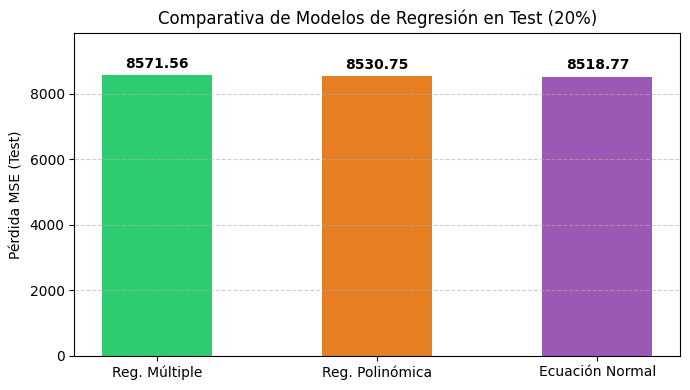

In [ ]:
# Gráficas comparativas de errores en el conjunto de Test
plt.figure(figsize=(7, 4))
modelos = ['Reg. Múltiple', 'Reg. Polinómica', 'Ecuación Normal']
mses_test = [loss_test_m.item(), loss_p_test.item(), loss_norm_test.item()]

bars = plt.bar(modelos, mses_test, color=['#2ecc71', '#e67e22', '#9b59b6'], width=0.5)
plt.ylabel('Pérdida MSE (Test)')
plt.title('Comparativa de Modelos de Regresión en Test (20%)')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

max_y = max(mses_test)
plt.ylim(0, max_y * 1.15)
offset = max_y * 0.015
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Regresión Logística Binaria (Lab 3)

In [ ]:
df_bin = pd.read_csv('/content/drive/MyDrive/InteligenciaArtificial/dataset.csv')
df_bin.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df_bin['es_popular'] = (df_bin['popularity'] >= 35).astype(int)

columnas_excluidas = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'popularity', 'es_popular']
columnas_features = [col for col in df_bin.columns if col not in columnas_excluidas and np.issubdtype(df_bin[col].dtype, np.number)]

X_bin = df_bin[columnas_features].values
y_bin = df_bin['es_popular'].values.reshape(-1, 1)

np.random.seed(42)
total_b = len(X_bin)
train_size_b = int(total_b * 0.8)

indices_b = np.random.permutation(total_b)
train_idx_b = indices_b[:train_size_b]
test_idx_b = indices_b[train_size_b:]

X_train_b, y_train_b = X_bin[train_idx_b], y_bin[train_idx_b]
X_test_b, y_test_b = X_bin[test_idx_b], y_bin[test_idx_b]

mu_b, std_b = X_train_b.mean(axis=0), X_train_b.std(axis=0)
std_b[std_b == 0] = 1.0

X_train_b_norm = (X_train_b - mu_b) / std_b
X_test_b_norm = (X_test_b - mu_b) / std_b

X_train_b_tensor = torch.tensor(X_train_b_norm, dtype=torch.float32).to(device)
y_train_b_tensor = torch.tensor(y_train_b, dtype=torch.float32).to(device)
X_test_b_tensor = torch.tensor(X_test_b_norm, dtype=torch.float32).to(device)
y_test_b_tensor = torch.tensor(y_test_b, dtype=torch.float32).to(device)

print(f'Train Binario (80%): {len(X_train_b)} canciones, Test Binario (20%): {len(X_test_b)} canciones')

Train Binario (80%): 91200 canciones, Test Binario (20%): 22800 canciones


In [ ]:
# Dataset y DataLoader (NUEVO)
train_dataset_b = TensorDataset(X_train_b_tensor, y_train_b_tensor)
train_loader_b = DataLoader(train_dataset_b, batch_size=64, shuffle=True)

In [ ]:
class RegresionLogisticaBinaria(nn.Module):
    def __init__(self, in_features):
        super(RegresionLogisticaBinaria, self).__init__()
        self.linear = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

In [ ]:
learning_rate_bin = 0.5
epochs_bin = 250

num_features = X_train_b_tensor.shape[1]
model_bin = RegresionLogisticaBinaria(in_features=num_features).to(device)
criterion_bce = nn.BCELoss()
optimizer_bin = optim.SGD(model_bin.parameters(), lr=learning_rate_bin)   # NUEVO

loss_history_bin = entrenar_modelo(model_bin, train_loader_b, criterion_bce, optimizer_bin, epochs_bin, imprimir_cada=50)

torch.save(model_bin.state_dict(), 'model_bin.pth')   # NUEVO
print(f'Pérdida final BCE Train: {loss_history_bin[-1]:.4f}')

Época [50/250], Pérdida Train: 0.6817
Época [100/250], Pérdida Train: 0.6813
Época [150/250], Pérdida Train: 0.6817
Época [200/250], Pérdida Train: 0.6815
Época [250/250], Pérdida Train: 0.6814
Pérdida final BCE Train: 0.6814


In [ ]:
# Evaluación + Métricas ampliadas (NUEVO: precision, recall, f1, matriz de confusión)
model_bin.eval()
with torch.no_grad():
    probs_test = model_bin(X_test_b_tensor)
    loss_b_test = criterion_bce(probs_test, y_test_b_tensor)
    preds_test = (probs_test >= 0.5).float()

y_true_bin = y_test_b_tensor.cpu().numpy()
y_pred_bin = preds_test.cpu().numpy()

accuracy = accuracy_score(y_true_bin, y_pred_bin)
precision = precision_score(y_true_bin, y_pred_bin)
recall = recall_score(y_true_bin, y_pred_bin)
f1 = f1_score(y_true_bin, y_pred_bin)
cm_bin = confusion_matrix(y_true_bin, y_pred_bin)

print(f'Regresión Logística Binaria -> Pérdida Test: {loss_b_test.item():.4f}')
print(f'Accuracy: {accuracy*100:.2f}% | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')
print('Matriz de Confusión:\n', cm_bin)

Regresión Logística Binaria -> Pérdida Test: 0.6767
Accuracy: 56.50% | Precision: 0.5643 | Recall: 0.5988 | F1: 0.5810
Matriz de Confusión:
 [[6003 5310]
 [4609 6878]]


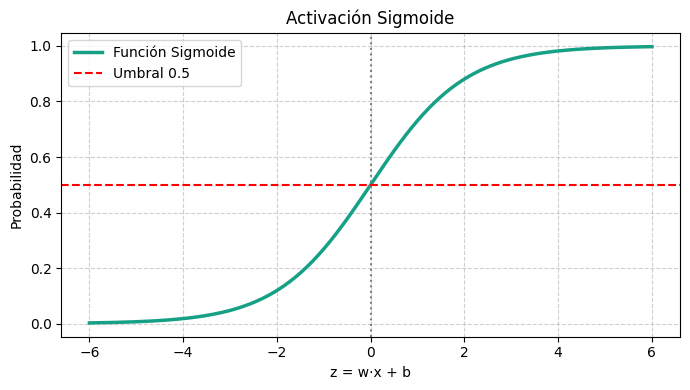

In [ ]:
# Gráfica de la función Sigmoide
plt.figure(figsize=(7, 4))
z = np.linspace(-6, 6, 200)
sig = 1 / (1 + np.exp(-z))
plt.plot(z, sig, color='#16a085', linewidth=2.5, label='Función Sigmoide')
plt.axhline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('z = w·x + b')
plt.ylabel('Probabilidad')
plt.title('Activación Sigmoide')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

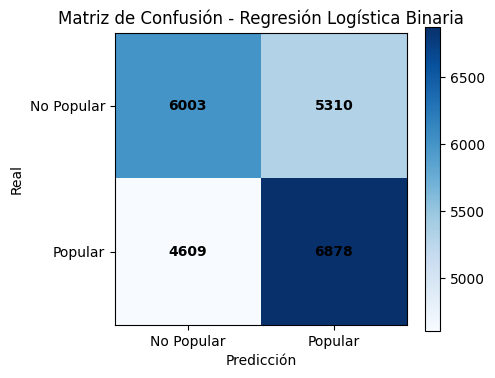

In [ ]:
# Matriz de confusión visual (NUEVO)
plt.figure(figsize=(5, 4))
plt.imshow(cm_bin, cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística Binaria')
plt.colorbar()
plt.xticks([0, 1], ['No Popular', 'Popular'])
plt.yticks([0, 1], ['No Popular', 'Popular'])
plt.xlabel('Predicción')
plt.ylabel('Real')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_bin[i, j]), ha='center', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Clasificación Multiclase (Lab 4)

In [4]:
df_multi_cls = pd.read_csv('/content/drive/MyDrive/InteligenciaArtificial/heart_disease_health_indicators_BRFSS2015.csv')
df_multi_cls.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
X_mc = df_multi_cls.drop(columns=['Diabetes']).values
y_mc = df_multi_cls['Diabetes'].values.astype(np.int64)

np.random.seed(42)
total_mc = len(X_mc)
train_size_mc = int(total_mc * 0.8)

indices_mc = np.random.permutation(total_mc)
train_idx_mc = indices_mc[:train_size_mc]
test_idx_mc = indices_mc[train_size_mc:]

X_train_mc, y_train_mc = X_mc[train_idx_mc], y_mc[train_idx_mc]
X_test_mc, y_test_mc = X_mc[test_idx_mc], y_mc[test_idx_mc]

mu_mc, std_mc = X_train_mc.mean(axis=0), X_train_mc.std(axis=0)
std_mc[std_mc == 0] = 1.0

X_train_mc_norm = (X_train_mc - mu_mc) / std_mc
X_test_mc_norm = (X_test_mc - mu_mc) / std_mc

X_train_mc_tensor = torch.tensor(X_train_mc_norm, dtype=torch.float32).to(device)
y_train_mc_tensor = torch.tensor(y_train_mc, dtype=torch.long).to(device)
X_test_mc_tensor = torch.tensor(X_test_mc_norm, dtype=torch.float32).to(device)
y_test_mc_tensor = torch.tensor(y_test_mc, dtype=torch.long).to(device)

num_classes = len(np.unique(y_mc))
num_features = X_mc.shape[1]

print(f'Características de Entrada: {num_features}, Clases K: {num_classes}')
print(f'Train Multiclase (80%): {len(X_train_mc)}, Test Multiclase (20%): {len(X_test_mc)}')

Características de Entrada: 21, Clases K: 3
Train Multiclase (80%): 202944, Test Multiclase (20%): 50736


In [11]:
# Dataset y DataLoader (NUEVO)
train_dataset_mc = TensorDataset(X_train_mc_tensor, y_train_mc_tensor)
train_loader_mc = DataLoader(train_dataset_mc, batch_size=64, shuffle=True)

### 1.3 Clases de Modelos (Regresión Logística Binaria)

La clase `RegresionLogisticaBinaria` ya está definida más adelante en la celda `4cf741a0`. Sin embargo, para asegurar que esté disponible antes de cualquier entrenamiento que la utilice y resolver el `NameError`, la volvemos a definir aquí junto con otras utilidades.

In [ ]:
class RegresionLogisticaBinaria(nn.Module):
    def __init__(self, in_features):
        super(RegresionLogisticaBinaria, self).__init__()
        self.linear = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))


In [17]:
# 1. One-vs-All: K clasificadores binarios
# Cada clasificador repite el entrenamiento sobre el mismo conjunto de características.
# Por eso conviene usar pocas épocas y lotes grandes.
learning_rate_ova = 0.5
epochs_ova = 50
batch_size_ova = min(1024, len(X_train_mc_tensor))

classifiers = []
for k in range(num_classes):
    y_k_train = (y_train_mc == k).astype(np.float32).reshape(-1, 1)
    y_k_tensor = torch.tensor(y_k_train, dtype=torch.float32, device=device)

    train_dataset_k = TensorDataset(X_train_mc_tensor, y_k_tensor)
    train_loader_k = DataLoader(train_dataset_k, batch_size=batch_size_ova, shuffle=True)

    model_k = RegresionLogisticaBinaria(in_features=num_features).to(device)
    criterion_k = nn.BCELoss()
    optimizer_k = optim.SGD(model_k.parameters(), lr=learning_rate_ova)

    entrenar_modelo(
        model_k,
        train_loader_k,
        criterion_k,
        optimizer_k,
        epochs_ova,
        imprimir_cada=max(1, epochs_ova // 5)
    )

    torch.save(model_k.state_dict(), f'model_ova_clase_{k}.pth')
    classifiers.append(model_k)

print(f'Se entrenaron y guardaron {len(classifiers)} clasificadores One-vs-All.')

Época [10/50], Pérdida Train: 0.3459
Época [20/50], Pérdida Train: 0.3459
Época [30/50], Pérdida Train: 0.3459
Época [40/50], Pérdida Train: 0.3459
Época [50/50], Pérdida Train: 0.3459
Época [10/50], Pérdida Train: 0.0868
Época [20/50], Pérdida Train: 0.0868
Época [30/50], Pérdida Train: 0.0868
Época [40/50], Pérdida Train: 0.0868
Época [50/50], Pérdida Train: 0.0868
Época [10/50], Pérdida Train: 0.3198
Época [20/50], Pérdida Train: 0.3198
Época [30/50], Pérdida Train: 0.3198
Época [40/50], Pérdida Train: 0.3198
Época [50/50], Pérdida Train: 0.3197
Se entrenaron y guardaron 3 clasificadores One-vs-All.


In [18]:
# Evaluación One-vs-All + métricas ampliadas
all_probs_test = []
for clf in classifiers:
    clf.eval()
    with torch.no_grad():
        all_probs_test.append(clf(X_test_mc_tensor).cpu().numpy())

all_probs_test = np.hstack(all_probs_test)
preds_ova_test = np.argmax(all_probs_test, axis=1)

acc_ova_test = accuracy_score(y_test_mc, preds_ova_test)
precision_ova = precision_score(y_test_mc, preds_ova_test, average='macro', zero_division=0)
recall_ova = recall_score(y_test_mc, preds_ova_test, average='macro', zero_division=0)
f1_ova = f1_score(y_test_mc, preds_ova_test, average='macro', zero_division=0)

print(f'One-vs-All -> Accuracy: {acc_ova_test*100:.2f}% | Precision (macro): {precision_ova:.4f} | Recall (macro): {recall_ova:.4f} | F1 (macro): {f1_ova:.4f}')

One-vs-All -> Accuracy: 84.55% | Precision (macro): 0.4579 | Recall (macro): 0.3874 | F1 (macro): 0.3972


In [19]:
class ClasificadorMulticlase(nn.Module):
    def __init__(self, in_features, num_classes):
        super(ClasificadorMulticlase, self).__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)

In [20]:
# 2. Softmax / CrossEntropy Nativo
learning_rate_native = 0.5
epochs_native = 250

model_native = ClasificadorMulticlase(num_features, num_classes).to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_native = optim.SGD(model_native.parameters(), lr=learning_rate_native)   # NUEVO

loss_history_native = entrenar_modelo(model_native, train_loader_mc, criterion_ce, optimizer_native, epochs_native, imprimir_cada=50)

torch.save(model_native.state_dict(), 'model_native.pth')   # NUEVO
print(f'Pérdida final CrossEntropy Train: {loss_history_native[-1]:.4f}')

Época [50/250], Pérdida Train: 0.4142
Época [100/250], Pérdida Train: 0.4137
Época [150/250], Pérdida Train: 0.4132
Época [200/250], Pérdida Train: 0.4142
Época [250/250], Pérdida Train: 0.4137
Pérdida final CrossEntropy Train: 0.4137


In [21]:
# Evaluación + métricas ampliadas
model_native.eval()
with torch.no_grad():
    logits_test = model_native(X_test_mc_tensor)
    preds_native_test = torch.argmax(logits_test, dim=1).cpu().numpy()

acc_native_test = accuracy_score(y_test_mc, preds_native_test)
precision_native = precision_score(y_test_mc, preds_native_test, average='macro', zero_division=0)
recall_native = recall_score(y_test_mc, preds_native_test, average='macro', zero_division=0)
f1_native = f1_score(y_test_mc, preds_native_test, average='macro', zero_division=0)
cm_native = confusion_matrix(y_test_mc, preds_native_test)

print(f'Softmax Nativo -> Accuracy: {acc_native_test*100:.2f}% | Precision (macro): {precision_native:.4f} | Recall (macro): {recall_native:.4f} | F1 (macro): {f1_native:.4f}')
print('Matriz de Confusión:\n', cm_native)

Softmax Nativo -> Accuracy: 84.33% | Precision (macro): 0.4505 | Recall (macro): 0.3644 | F1 (macro): 0.3650
Matriz de Confusión:
 [[42006     0   743]
 [  885     0    47]
 [ 6274     0   781]]


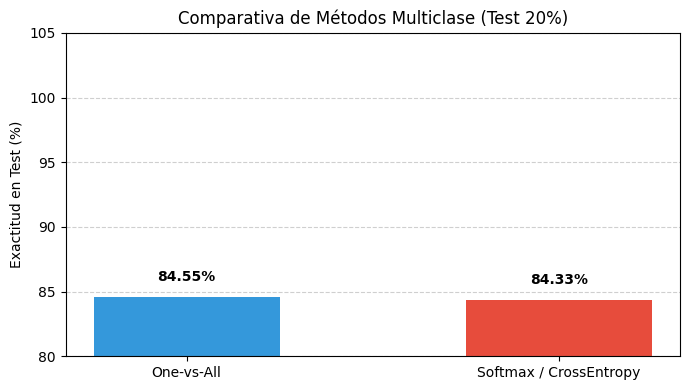

In [22]:
# Gráfica comparativa de Métodos Multiclase en Test (20%)
plt.figure(figsize=(7, 4))
metodos = ['One-vs-All', 'Softmax / CrossEntropy']
exactitudes = [acc_ova_test * 100, acc_native_test * 100]

bars = plt.bar(metodos, exactitudes, color=['#3498db', '#e74c3c'], width=0.5)
plt.ylabel('Exactitud en Test (%)')
plt.ylim(80, 105)
plt.title('Comparativa de Métodos Multiclase (Test 20%)')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Clasificación Multiclase de Imágenes con MNIST (Lab 5)

Dataset gráfico con imágenes de $28\times28$ píxeles (cumple el requisito de resolución $\geq 20\times20$) y $70{,}000$ ejemplos en total (cumple $m \geq 50{,}000$). Cada imagen representa un dígito escrito a mano (0 al 9), por lo que es un problema de clasificación multiclase con $K=10$ clases.

Aunque MNIST ya viene dividido en train/test, **unimos ambas partes y hacemos nuestra propia división manual 80% / 20%**, igual que en los laboratorios anteriores.

In [5]:
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset

# Transformación: convertir a escala de grises (1 canal) y a tensor (ya normaliza a [0, 1])
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# AJUSTA estas dos rutas
ruta_train = '/content/drive/MyDrive/InteligenciaArtificial/Fashion-MNIST/train'
ruta_test = '/content/drive/MyDrive/InteligenciaArtificial/Fashion-MNIST/test'

# ImageFolder lee automáticamente las subcarpetas (0, 1, 2, ..., 9) como las clases
dataset_train_raw = datasets.ImageFolder(root=ruta_train, transform=transform)
dataset_test_raw = datasets.ImageFolder(root=ruta_test, transform=transform)

print(f'Clases detectadas (según nombre de carpeta): {dataset_train_raw.classes}')
print(f'Imágenes en train: {len(dataset_train_raw)}, imágenes en test: {len(dataset_test_raw)}')

Clases detectadas (según nombre de carpeta): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Imágenes en train: 60013, imágenes en test: 10000


In [6]:
# 3. Cargar imágenes a tensores y aplanar respetando el split original

def dataset_a_tensores(dataset):
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)
    X_list, y_list = [], []
    for imgs, labels in loader:
        X_list.append(imgs)
        y_list.append(labels)
    X = torch.cat(X_list, dim=0)
    y = torch.cat(y_list, dim=0)
    # Aplanar las imágenes de (N, 1, 28, 28) a (N, 784)
    X = X.view(X.shape[0], -1)
    return X, y

X_train_mnist, y_train_mnist = dataset_a_tensores(dataset_train_raw)
X_test_mnist, y_test_mnist = dataset_a_tensores(dataset_test_raw)

# Mover tensores al dispositivo correspondiente (GPU/CPU)
X_train_mnist = X_train_mnist.to(device)
y_train_mnist = y_train_mnist.to(device)
X_test_mnist = X_test_mnist.to(device)
y_test_mnist = y_test_mnist.to(device)

print(f'Conjunto Train: {X_train_mnist.shape[0]} imágenes de dimensión {X_train_mnist.shape[1]}')
print(f'Conjunto Test:  {X_test_mnist.shape[0]} imágenes de dimensión {X_test_mnist.shape[1]}')

KeyboardInterrupt: 

In [ ]:
# 4. Crear Datasets y DataLoaders utilizando la división nativa
train_dataset_mnist = TensorDataset(X_train_mnist, y_train_mnist)
train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=128, shuffle=True)

In [ ]:
# Modelo: red neuronal simple de una capa oculta (mismo estilo nn.Module que el resto del notebook)
class ClasificadorMNIST(nn.Module):
    def __init__(self, in_features, num_classes):
        super(ClasificadorMNIST, self).__init__()
        self.hidden = nn.Linear(in_features, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.relu(self.hidden(x))
        return self.output(x)

In [ ]:
learning_rate_mnist = 0.001
epochs_mnist = 10

num_features_mnist = X_train_mnist.shape[1]   # 784
num_classes_mnist = 10

model_mnist = ClasificadorMNIST(num_features_mnist, num_classes_mnist).to(device)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(model_mnist.parameters(), lr=learning_rate_mnist)   # Adam converge más rápido en redes con capas ocultas

loss_history_mnist = entrenar_modelo(model_mnist, train_loader_mnist, criterion_mnist, optimizer_mnist, epochs_mnist, imprimir_cada=1)

In [ ]:
# Guardar los pesos del modelo entrenado (NUEVO)
torch.save(model_mnist.state_dict(), 'model_mnist.pth')
print('Pesos guardados en model_mnist.pth')

In [ ]:
# Evaluación en Test + Métricas completas (NUEVO)
model_mnist.eval()
with torch.no_grad():
    logits_test_mnist = model_mnist(X_test_mnist)
    preds_mnist = torch.argmax(logits_test_mnist, dim=1).cpu().numpy()

y_true_mnist = y_test_mnist.cpu().numpy()

acc_mnist = accuracy_score(y_true_mnist, preds_mnist)
precision_mnist = precision_score(y_true_mnist, preds_mnist, average='macro')
recall_mnist = recall_score(y_true_mnist, preds_mnist, average='macro')
f1_mnist = f1_score(y_true_mnist, preds_mnist, average='macro')
cm_mnist = confusion_matrix(y_true_mnist, preds_mnist)

print(f'MNIST -> Accuracy: {acc_mnist*100:.2f}% | Precision (macro): {precision_mnist:.4f} | Recall (macro): {recall_mnist:.4f} | F1 (macro): {f1_mnist:.4f}')

In [ ]:
# Gráfica de la curva de costo durante el entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs_mnist + 1), loss_history_mnist, color='#2980b9', linewidth=2, marker='o')
plt.xlabel('Épocas')
plt.ylabel('Pérdida CrossEntropy')
plt.title('Curva de Costo - Clasificador Fashion-MNIST')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Matriz de confusión visual (10 clases)
plt.figure(figsize=(7, 6))
plt.imshow(cm_mnist, cmap='Blues')
plt.title('Matriz de Confusión - Fashion-MNIST (Test 20%)')
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('Predicción')
plt.ylabel('Dígito Real')
for i in range(10):
    for j in range(10):
        color = 'white' if cm_mnist[i, j] > cm_mnist.max() / 2 else 'black'
        plt.text(j, i, str(cm_mnist[i, j]), ha='center', va='center', color=color, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplos de predicciones sobre el conjunto de Test (demuestra la efectividad del modelo)
# dataset_train_raw.classes trae el nombre de carpeta de cada clase ('0'..'9');
# aquí los mapeamos al nombre real de la prenda según el estándar de Fashion-MNIST
nombres_clases = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                   'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
indices_muestra = np.random.choice(len(X_test_mnist), 10, replace=False)

for ax, idx in zip(axes.flatten(), indices_muestra):
    imagen = X_test_mnist[idx].cpu().numpy().reshape(28, 28)
    real = y_true_mnist[idx]
    pred = preds_mnist[idx]

    ax.imshow(imagen, cmap='gray')
    color_titulo = 'green' if real == pred else 'red'
    ax.set_title(f'Real: {nombres_clases[real]}\nPred: {nombres_clases[pred]}', color=color_titulo, fontsize=9)
    ax.axis('off')

plt.suptitle('Predicciones del Clasificador Fashion-MNIST sobre el Test (20%)')
plt.tight_layout()
plt.show()

## 7. Resumen Final de Checkpoints y Métricas

| Lab | Modelo | Checkpoint guardado | Métrica principal (Test) |
|---|---|---|---|
| 1 | Regresión Lineal Simple | `model_simple.pth` | MSE, MAE, R² |
| 2 | Regresión Múltiple / Polinómica / Ec. Normal | `model_multi.pth`, `model_poly.pth`, `model_ecuacion_normal.pth` | MSE, MAE, R² |
| 3 | Regresión Logística Binaria | `model_bin.pth` | Accuracy, Precision, Recall, F1 |
| 4 | Multiclase (One-vs-All / Softmax) | `model_ova_clase_k.pth`, `model_native.pth` | Accuracy, Precision, Recall, F1 (macro) |
| 5 | Fashion-MNIST (Red Neuronal) | `model_mnist.pth` | Accuracy, Precision, Recall, F1 (macro) |

Todos los modelos ahora se entrenan con `Dataset` + `DataLoader` (mini-batches), se optimizan con un objeto `optimizer` de `torch.optim`, guardan sus pesos entrenados con `torch.save`, y se evalúan con un conjunto de métricas más completo que solo la pérdida.